# PyTorch로 구현하는 SVM 문자 분류 실습

- `LinearSVMClassifier`: 선형 SVM 구조(데이터를 직선(초평면)으로 분리하는 것)<br>
SVM은 두 클래스를 가장 잘 나누는 경계선을 찾는다.

예:

O O O O

----------- ← 결정 경계(Hyperplane)

X X X X

이 경계를:

초평면(Hyperplane) 이라고 한다.

- `RBFFeatureSVMClassifier`: RBF 커널 효과를 근사하는 Random Fourier Features + SVM 구조

이 구조는:

RBF 커널 SVM 효과를
PyTorch에서 근사(Approximation)한 구조이다.

핵심:

Random Fourier Features(RFF)

를 사용한다.

* 왜 필요한가?

선형 SVM은:

X O X O X O

같이 복잡하게 섞인 데이터는:

직선으로 분리 불가능하다.

RBF 커널은:

데이터를 고차원 공간으로 변환해서
선형 분리 가능하게 만든다.

대표 수식:

K(x,x
′
)=exp(−γ∣∣x−x
′
∣∣
2
)

의미:

- 가까운 점은 높은 유사도
- 먼 점은 낮은 유사도

* 문제점

진짜 RBF 커널 SVM은계산량이 매우 크다.

특히:

데이터가 많으면 느려진다.

* 해결 방법 → Random Fourier Features

RFF는RBF 커널을 근사한다.

즉:

원본 입력 x

    ↓

랜덤 고차원 변환

    ↓

새로운 feature 공간

    ↓
    
Linear SVM 적용

In [1]:
# ============================================================
# 0. 실습 환경 확인
# ============================================================

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 연산, 자동 미분, 신경망 모델 작성에 사용합니다.
import torch

# torch.nn은 PyTorch에서 모델 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.nn.functional은 활성화 함수, 손실 함수 등을 함수 형태로 제공합니다.
import torch.nn.functional as F

# torch.utils.data는 Dataset, DataLoader를 제공하여 데이터를 미니배치로 나누어 학습할 수 있게 합니다.
from torch.utils.data import TensorDataset, DataLoader

# pandas는 CSV 파일을 읽고 표 형태 데이터프레임으로 다루기 위해 사용합니다.
import pandas as pd

# numpy는 수치 계산 및 배열 처리를 위해 사용합니다.
import numpy as np

# matplotlib은 학습 결과 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# sklearn의 LabelEncoder는 문자 A~Z 같은 범주형 라벨을 0~25 숫자로 변환합니다.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# sklearn의 confusion_matrix, classification_report는 분류 성능 평가에 사용합니다.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# os는 파일 경로 존재 여부를 확인하기 위해 사용합니다.
import os

# urllib.request는 Colab에서 데이터 파일이 없을 때 인터넷에서 데이터를 내려받기 위해 사용합니다.
import urllib.request

# random은 파이썬 기본 난수 생성을 제어하기 위해 사용합니다.
import random

# 실행 장치를 설정합니다.
# GPU가 있으면 cuda, 없으면 cpu를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cpu


In [2]:
# ============================================================
# 1. 재현 가능한 실험을 위한 시드 고정
# ============================================================

# 같은 코드를 여러 번 실행해도 가능한 한 비슷한 결과가 나오도록 난수 시드를 고정합니다.
SEED = 12345

# 파이썬 random 모듈의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 사용 가능한 경우 GPU 난수 시드도 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("난수 시드 고정 완료:", SEED)

난수 시드 고정 완료: 12345


## 1단계. 데이터 준비

CSV 파일을 읽습니다.
Colab에서는 `/content/data/opt_letterdata.csv` 위치에 파일이 있으면 그 파일을 사용합니다.  
파일이 없으면 UCI Letter Recognition 데이터셋 형식과 동일한 데이터를 인터넷에서 내려받아 사용합니다.

데이터 컬럼 구조:

- `letter`: 정답 라벨, A~Z
- 나머지 16개 컬럼: 글자 이미지에서 추출된 수치 특징

In [3]:
# ============================================================
# 2. 데이터 파일 준비
# ============================================================

# Colab에서 사용할 데이터 폴더 경로를 지정합니다.
DATA_DIR = "/content/data"

# 데이터 폴더가 없으면 생성합니다.
os.makedirs(DATA_DIR, exist_ok=True)

# 사용할 CSV 파일 경로를 지정합니다.
csv_path = os.path.join(DATA_DIR, "opt_letterdata.csv")

# CSV 파일이 없는 경우 UCI Letter Recognition 데이터를 내려받습니다.
if not os.path.exists(csv_path):
    # UCI Letter Recognition 데이터셋 URL입니다.
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"

    # 임시 원본 데이터 파일 경로입니다.
    raw_path = os.path.join(DATA_DIR, "letter-recognition.data")

    # 인터넷에서 데이터를 다운로드합니다.
    urllib.request.urlretrieve(url, raw_path)

    # UCI 데이터셋은 헤더가 없으므로 컬럼명을 직접 지정합니다.
    columns = [
        "letter", "x_box", "y_box", "width", "height", "onpix", "x_bar", "y_bar",
        "x2bar", "y2bar", "xybar", "x2ybr", "xy2br", "x_ege", "xegvy",
        "y_ege", "yegvx"
    ]

    # CSV 파일을 pandas DataFrame으로 읽습니다.
    df_raw = pd.read_csv(raw_path, header=None, names=columns)

    # CSV 파일 형태로 저장합니다.
    df_raw.to_csv(csv_path, index=False)

    print("데이터 다운로드 및 CSV 저장 완료:", csv_path)
else:
    print("기존 CSV 파일 사용:", csv_path)

# CSV 파일을 pandas DataFrame으로 읽습니다.
df = pd.read_csv(csv_path)

# 데이터 앞부분 5개 행을 출력하여 구조를 확인합니다.
df.head()

데이터 다운로드 및 CSV 저장 완료: /content/data/opt_letterdata.csv


,letter,x_box,y_box,width,height,onpix,x_bar,y_bar,x2bar,y2bar,xybar,x2ybr,xy2br,x_ege,xegvy,y_ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [4]:
# ============================================================
# 3. 데이터 구조 확인
# ============================================================

# 데이터 행과 열의 개수를 확인합니다.
print("데이터 크기:", df.shape)

# 각 컬럼의 자료형과 결측치 여부를 확인합니다.
print("\n데이터 정보:")
print(df.info())

# 정답 라벨인 letter 컬럼의 종류와 개수를 확인합니다.
print("\n문자 라벨 개수:")
print(df["letter"].value_counts().sort_index())

데이터 크기: (20000, 17)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   x_box   20000 non-null  int64 
 2   y_box   20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   x_bar   20000 non-null  int64 
 7   y_bar   20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybr   20000 non-null  int64 
 12  xy2br   20000 non-null  int64 
 13  x_ege   20000 non-null  int64 
 14  xegvy   20000 non-null  int64 
 15  y_ege   20000 non-null  int64 
 16  yegvx   20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB
None

문자 라벨 개수:
letter
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    

## 2단계. 입력 데이터와 정답 데이터 분리

의미:

- `letter`: 정답 변수
- `.`: 나머지 모든 컬럼을 입력 특징으로 사용


In [5]:
# ============================================================
# 4. 입력 X와 정답 y 분리
# ============================================================

# letter 컬럼은 정답 라벨이므로 y로 사용합니다.
y_text = df["letter"].values

# letter를 제외한 나머지 컬럼들은 입력 특징 X로 사용합니다.
X = df.drop(columns=["letter"]).values

# LabelEncoder는 A~Z 문자를 0~25 정수 라벨로 변환합니다.
label_encoder = LabelEncoder()

# 문자 라벨을 숫자 라벨로 변환합니다.
y = label_encoder.fit_transform(y_text)

# 입력 데이터 X를 실수형 float32로 변환합니다.
# PyTorch 모델은 일반적으로 float32 텐서를 사용합니다.
X = X.astype(np.float32)

# 정답 데이터 y를 정수형 int64로 변환합니다.
# PyTorch의 분류 손실 함수는 클래스(category) 라벨을 long 타입으로 받습니다.
y = y.astype(np.int64)

# 클래스 개수를 계산합니다.
num_classes = len(label_encoder.classes_)

# 입력 특징 개수를 계산합니다.
num_features = X.shape[1]

print("입력 특징 수:", num_features)
print("클래스 수:", num_classes)
print("클래스 목록:", label_encoder.classes_)

입력 특징 수: 16
클래스 수: 26
클래스 목록: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


## 3단계. 훈련 데이터와 테스트 데이터 분리
```
opt_letters_train <- opt_letters[1:16000, ]
opt_letters_test  <- opt_letters[16001:20000, ]
```

즉, 앞의 16,000개는 훈련용, 뒤의 4,000개는 테스트용으로 사용합니다.

In [6]:
# ============================================================
# 5. 훈련 데이터와 테스트 데이터 분리
# ============================================================

# 앞 16000개 행을 훈련 데이터로 사용합니다.
X_train = X[:16000]

# 앞 16000개 행의 라벨을 훈련 정답으로 사용합니다.
y_train = y[:16000]

# 16001번째 이후 행을 테스트 데이터로 사용합니다.
X_test = X[16000:]

# 16001번째 이후 라벨을 테스트 정답으로 사용합니다.
y_test = y[16000:]

print("훈련 X:", X_train.shape)
print("훈련 y:", y_train.shape)
print("테스트 X:", X_test.shape)
print("테스트 y:", y_test.shape)

훈련 X: (16000, 16)
훈련 y: (16000,)
테스트 X: (4000, 16)
테스트 y: (4000,)


## 4단계. 데이터 정규화

SVM은 경계와 거리 개념을 사용하는 알고리즘이므로 입력 특징의 스케일이 중요합니다.  
따라서 평균 0, 표준편차 1이 되도록 표준화합니다.

주의:

- 훈련 데이터로만 `fit`
- 테스트 데이터는 훈련 데이터 기준으로 `transform`

이렇게 해야 테스트 데이터 정보가 학습에 새어 들어가지 않습니다.

In [7]:
# ============================================================
# 6. 표준화 전처리
# ============================================================

# StandardScaler는 각 특징을 평균 0, 표준편차 1로 변환합니다.
scaler = StandardScaler()

# 훈련 데이터의 평균과 표준편차를 학습하고 동시에 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 훈련 데이터에서 학습한 평균과 표준편차로만 변환합니다.
X_test_scaled = scaler.transform(X_test)

# numpy 배열을 PyTorch 텐서로 변환합니다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

# 훈련 정답도 PyTorch 텐서로 변환합니다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

# 테스트 입력을 PyTorch 텐서로 변환합니다.
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 테스트 정답을 PyTorch 텐서로 변환합니다.
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("PyTorch 텐서 변환 완료")
print(X_train_tensor.shape, y_train_tensor.shape)

PyTorch 텐서 변환 완료
torch.Size([16000, 16]) torch.Size([16000])


In [8]:
# ============================================================
# 7. DataLoader 생성
# ============================================================

# TensorDataset은 입력 텐서와 정답 텐서를 하나의 데이터셋으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 데이터를 batch_size 단위로 나누어 모델에 공급합니다.
train_loader = DataLoader(
    train_dataset,       # 학습에 사용할 데이터셋입니다.
    batch_size=256,      # 한 번에 256개 샘플씩 학습합니다.
    shuffle=True         # 매 epoch마다 데이터 순서를 섞어 학습 안정성을 높입니다.
)

print("미니배치 개수:", len(train_loader))

미니배치 개수: 63


## 5단계. PyTorch SVM 모델 클래스 작성

전통적인 SVM은 다음과 같은 결정 경계를 학습합니다.

```text
wᵀx + b = 0
```

다중 클래스 분류에서는 클래스마다 하나의 점수(score)를 계산하고, 가장 큰 점수를 가진 클래스(category)를 예측합니다.

여기서는 `nn.Linear`를 사용하여 선형 결정 경계를 만들고,  
손실 함수는 다중 클래스 SVM의 hinge loss를 직접 작성합니다.

In [9]:
# ============================================================
# 8. 다중 클래스 SVM 손실 함수 정의
# ============================================================

class MultiClassHingeLoss(nn.Module):
    # nn.Module을 상속하여 PyTorch 손실 함수 클래스를 만듭니다.
    def __init__(self, margin=1.0):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # margin은 정답 클래스 점수가 다른 클래스보다 최소한 얼마나 커야 하는지를 의미합니다.
        self.margin = margin

    def forward(self, scores, targets):
        # scores: 모델이 출력한 클래스별 점수, 크기 [batch_size, num_classes]
        # targets: 실제 정답 클래스 번호, 크기 [batch_size]

        # 배치 데이터 개수를 가져옵니다.
        batch_size = scores.size(0)

        # 각 샘플의 정답 클래스 점수만 뽑아냅니다.
        correct_scores = scores[torch.arange(batch_size), targets].view(-1, 1)

        # SVM hinge loss 계산식입니다.
        # 정답이 아닌 클래스 점수 - 정답 클래스 점수 + margin 이 0보다 크면 손실이 발생합니다.
        margins = torch.clamp(scores - correct_scores + self.margin, min=0.0)

        # 정답 클래스 자체에 대한 margin은 손실에서 제외해야 하므로 0으로 만듭니다.
        margins[torch.arange(batch_size), targets] = 0.0

        # 모든 샘플과 클래스에 대한 평균 손실을 반환합니다.
        loss = margins.sum(dim=1).mean()

        return loss

In [10]:
# ============================================================
# 9. 선형 SVM 모델 클래스 정의
# ============================================================

class LinearSVMClassifier(nn.Module):
    # nn.Module을 상속하여 PyTorch 모델 클래스를 작성합니다.
    def __init__(self, input_dim, num_classes):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # 선형 계층입니다.
        # 입력 특징 수 input_dim을 클래스 수 num_classes 점수로 변환합니다.
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # forward는 모델이 입력 x를 받아 출력 scores를 만드는 함수입니다.
        # 여기서 scores는 확률이 아니라 클래스(category)별 점수입니다.
        scores = self.linear(x)

        # 계산된 클래스별 점수를 반환합니다.
        return scores

## 6단계. 학습 함수 작성

머신러닝 전체 흐름에서 학습 단계는 다음 과정을 반복합니다.

1. 모델에 입력 데이터를 넣어 예측 점수 계산
2. 손실 함수로 오차 계산
3. `backward()`로 기울기 계산
4. optimizer로 파라미터 업데이트

In [11]:
# ============================================================
# 10. 모델 학습 함수 정의
# ============================================================

def train_model(model, train_loader, criterion, optimizer, epochs=30, l2_lambda=0.0):
    # model: 학습할 PyTorch 모델입니다.
    # train_loader: 미니배치 단위로 데이터를 공급하는 DataLoader입니다.
    # criterion: 손실 함수입니다.
    # optimizer: 모델 파라미터를 업데이트하는 최적화 알고리즘입니다.
    # epochs: 전체 데이터를 몇 번 반복 학습할지 정합니다.
    # l2_lambda: SVM의 C와 반대 성격에 가까운 L2 규제 강도입니다.

    # epoch별 평균 손실을 저장할 리스트입니다.
    loss_history = []

    # 모델을 학습 모드로 전환합니다.
    model.train()

    # 지정된 epoch 수만큼 반복합니다.
    for epoch in range(epochs):
        # 한 epoch 동안의 손실 합계를 저장합니다.
        total_loss = 0.0

        # DataLoader에서 미니배치 데이터를 하나씩 꺼냅니다.
        for batch_X, batch_y in train_loader:
            # 입력 데이터를 GPU 또는 CPU 장치로 이동합니다.
            batch_X = batch_X.to(device)

            # 정답 데이터를 GPU 또는 CPU 장치로 이동합니다.
            batch_y = batch_y.to(device)

            # 이전 배치에서 계산된 기울기를 초기화합니다.
            optimizer.zero_grad()

            # 모델에 입력 데이터를 넣어 클래스별 점수를 계산합니다.
            scores = model(batch_X)

            # SVM hinge loss를 계산합니다.
            loss = criterion(scores, batch_y)

            # L2 규제 항을 추가합니다.
            # SVM은 마진 최대화를 위해 가중치 크기를 제어하는 규제를 사용합니다.
            if l2_lambda > 0:
                l2_norm = sum(torch.sum(param ** 2) for param in model.parameters())
                loss = loss + l2_lambda * l2_norm

            # 손실에 대한 기울기를 자동 계산합니다.
            loss.backward()

            # 계산된 기울기를 이용해 모델 파라미터를 업데이트합니다.
            optimizer.step()

            # 현재 배치 손실을 누적합니다.
            total_loss += loss.item()

        # 한 epoch의 평균 손실을 계산합니다.
        avg_loss = total_loss / len(train_loader)

        # 평균 손실을 리스트에 저장합니다.
        loss_history.append(avg_loss)

        # 5 epoch마다 학습 상황을 출력합니다.
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # 학습 손실 기록을 반환합니다.
    return loss_history

In [12]:
# ============================================================
# 11. 평가 함수 정의
# ============================================================

def evaluate_model(model, X_tensor, y_tensor):
    # model: 평가할 PyTorch 모델입니다.
    # X_tensor: 평가 입력 데이터입니다.
    # y_tensor: 실제 정답 데이터입니다.

    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 평가에서는 기울기를 계산할 필요가 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        # 입력 데이터를 장치로 이동합니다.
        X_tensor = X_tensor.to(device)

        # 모델이 클래스별 점수를 출력합니다.
        scores = model(X_tensor)

        # 가장 높은 점수를 가진 클래스 번호를 예측값으로 선택합니다.
        preds = torch.argmax(scores, dim=1)

        # 예측값을 CPU numpy 배열로 변환합니다.
        preds_np = preds.cpu().numpy()

        # 실제 정답도 numpy 배열로 변환합니다.
        y_np = y_tensor.cpu().numpy()

        # 정확도를 계산합니다.
        acc = accuracy_score(y_np, preds_np)

    # 정확도와 예측 결과를 반환합니다.
    return acc, preds_np

## 7단계. 선형 SVM 학습

선형 SVM:

```
letter_classifier <- ksvm(letter ~ ., data = opt_letters_train, kernel = "vanilladot")
```

PyTorch 변환:

- `LinearSVMClassifier`
- `MultiClassHingeLoss`
- `Adam` optimizer
- L2 규제 적용

In [13]:
# ============================================================
# 12. 선형 SVM 모델 생성 및 학습
# ============================================================

# 선형 SVM 모델 객체를 생성합니다.
linear_svm = LinearSVMClassifier(
    input_dim=num_features,     # 입력 특징 개수입니다.
    num_classes=num_classes     # 분류할 클래스 개수입니다.
).to(device)

# 다중 클래스 hinge loss 객체를 생성합니다.
criterion = MultiClassHingeLoss(margin=1.0)

# Adam optimizer를 사용하여 모델 파라미터를 업데이트합니다.
optimizer = torch.optim.Adam(
    linear_svm.parameters(),    # 학습할 모델 파라미터입니다.
    lr=0.01                     # 학습률입니다.
)

# 선형 SVM 모델을 학습합니다.
linear_loss_history = train_model(
    model=linear_svm,           # 학습할 모델입니다.
    train_loader=train_loader,  # 훈련 데이터 로더입니다.
    criterion=criterion,        # SVM 손실 함수입니다.
    optimizer=optimizer,        # 최적화 알고리즘입니다.
    epochs=50,                  # 전체 데이터를 50번 반복 학습합니다.
    l2_lambda=1e-4              # L2 규제 강도입니다.
)

Epoch [5/50], Loss: 2.4724
Epoch [10/50], Loss: 2.0911
Epoch [15/50], Loss: 1.9558
Epoch [20/50], Loss: 1.9110
Epoch [25/50], Loss: 1.8726
Epoch [30/50], Loss: 1.8513
Epoch [35/50], Loss: 1.8431
Epoch [40/50], Loss: 1.8344
Epoch [45/50], Loss: 1.8260
Epoch [50/50], Loss: 1.8284


In [14]:
# ============================================================
# 13. 선형 SVM 평가
# ============================================================

# 테스트 데이터로 선형 SVM 모델 성능을 평가합니다.
linear_acc, linear_preds = evaluate_model(linear_svm, X_test_tensor, y_test_tensor)

# 정확도를 출력합니다.
print(f"선형 SVM 테스트 정확도: {linear_acc:.4f}")

# 숫자 예측값을 문자 라벨로 다시 변환합니다.
linear_pred_letters = label_encoder.inverse_transform(linear_preds)

# 예측 결과 일부를 출력합니다.
print("예측 문자 일부:", linear_pred_letters[:20])

선형 SVM 테스트 정확도: 0.7117
예측 문자 일부: ['W' 'N' 'R' 'X' 'N' 'H' 'E' 'Y' 'G' 'E' 'N' 'I' 'G' 'L' 'G' 'M' 'M' 'D'
 'F' 'R']


In [15]:
# ============================================================
# 14. 선형 SVM 혼동 행렬 및 분류 리포트
# ============================================================

# 혼동 행렬을 계산합니다.
cm_linear = confusion_matrix(y_test, linear_preds)

# 혼동 행렬을 DataFrame으로 변환하여 보기 쉽게 만듭니다.
cm_linear_df = pd.DataFrame(
    cm_linear,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

# 혼동 행렬을 출력합니다.
cm_linear_df

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
A,137,0,0,2,0,0,0,0,0,1,...,2,2,4,0,1,0,1,0,3,1
B,0,102,0,1,0,3,0,2,3,2,...,3,7,8,0,0,0,0,0,0,0
C,0,0,101,0,5,1,7,0,0,0,...,0,0,0,3,4,1,0,0,0,0
D,0,11,0,134,0,0,0,3,0,1,...,1,3,2,2,0,0,0,0,0,1
E,0,6,2,0,108,1,11,0,0,0,...,2,3,3,5,0,0,0,3,0,4
F,0,1,1,1,2,110,4,2,0,1,...,0,0,2,13,0,0,1,1,5,0
G,0,1,30,1,0,1,61,6,0,0,...,34,6,5,0,0,3,0,0,0,0
H,0,1,1,7,0,1,2,64,0,2,...,2,15,0,4,8,5,0,2,1,0
I,0,0,0,5,0,6,0,0,126,5,...,1,0,6,0,0,0,0,10,1,2
J,7,0,0,4,0,4,0,0,8,114,...,3,0,3,0,0,0,0,0,0,4


In [16]:
# ============================================================
# 15. 선형 SVM 분류 리포트 출력
# ============================================================

# precision, recall, f1-score를 포함한 분류 성능 리포트를 출력합니다.
print(classification_report(
    y_test,
    linear_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

           A       0.84      0.88      0.86       156
           B       0.65      0.75      0.70       136
           C       0.67      0.71      0.69       142
           D       0.72      0.80      0.76       167
           E       0.81      0.71      0.76       152
           F       0.65      0.72      0.69       153
           G       0.52      0.37      0.43       164
           H       0.43      0.42      0.43       151
           I       0.88      0.76      0.82       165
           J       0.78      0.77      0.78       148
           K       0.59      0.70      0.64       146
           L       0.74      0.75      0.75       157
           M       0.82      0.83      0.82       144
           N       0.77      0.77      0.77       166
           O       0.56      0.40      0.46       139
           P       0.88      0.71      0.79       168
           Q       0.59      0.65      0.62       168
           R       0.62    

## 8단계. RBF 커널 효과를 PyTorch로 구현하기

성능 개선 단계:

```
rbf_letter_classifier <- ksvm(letter ~ ., data = opt_letters_train, kernel = "rbfdot")
```

정확한 커널 SVM은 전체 샘플 간 커널 행렬을 계산하므로 PyTorch 학습 예제로는 무겁습니다.  
여기서는 RBF 커널 효과를 이해하기 위해 `Random Fourier Features`를 사용합니다.

핵심 아이디어:

1. 원본 입력 `x`를 RBF 커널과 유사한 고차원 특징 공간 `z(x)`로 변환
2. 변환된 특징 위에서 선형 SVM 학습
3. 결과적으로 비선형 결정 경계를 학습

In [17]:
# ============================================================
# 16. RBF 특징 근사 + SVM 모델 클래스 정의
# ============================================================

class RBFFeatureSVMClassifier(nn.Module):
    # Random Fourier Features로 RBF 커널 효과를 근사하는 SVM 모델입니다.
    def __init__(self, input_dim, num_classes, rbf_dim=512, gamma=0.1):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # rbf_dim은 RBF 근사 특징의 차원 수입니다.
        self.rbf_dim = rbf_dim

        # gamma는 RBF 커널의 영향 범위를 조절합니다.
        # gamma가 크면 가까운 점에만 강하게 반응하고, 작으면 넓게 반응합니다.
        self.gamma = gamma

        # Random Fourier Features에서 사용할 무작위 가중치 W입니다.
        # RBF 커널 근사를 위해 정규분포에서 샘플링합니다.
        W = torch.randn(input_dim, rbf_dim) * np.sqrt(2 * gamma)

        # 학습되지 않는 버퍼로 등록합니다.
        # 모델과 함께 device 이동은 되지만 optimizer가 업데이트하지 않습니다.
        self.register_buffer("W", W)

        # 무작위 위상 b입니다.
        b = 2 * np.pi * torch.rand(rbf_dim)

        # b도 학습되지 않는 버퍼로 등록합니다.
        self.register_buffer("b", b)

        # 변환된 RBF 근사 특징을 클래스 점수로 바꾸는 선형 계층입니다.
        self.linear = nn.Linear(rbf_dim, num_classes)

    def rbf_features(self, x):
        # 입력 x를 Random Fourier Features로 변환합니다.

        # x @ W + b를 계산합니다.
        projection = x @ self.W + self.b

        # cos 변환을 적용하여 비선형 특징을 만듭니다.
        z = torch.cos(projection)

        # 특징 크기를 안정적으로 맞추기 위해 sqrt(2 / rbf_dim)를 곱합니다.
        z = z * np.sqrt(2.0 / self.rbf_dim)

        # 변환된 특징을 반환합니다.
        return z

    def forward(self, x):
        # 입력 x를 RBF 근사 특징으로 변환합니다.
        z = self.rbf_features(x)

        # 변환된 특징으로 클래스별 점수를 계산합니다.
        scores = self.linear(z)

        # 클래스별 점수를 반환합니다.
        return scores

In [18]:
# ============================================================
# 17. RBF 특징 SVM 모델 생성 및 학습
# ============================================================

# RBF 특징 SVM 모델 객체를 생성합니다.
rbf_svm = RBFFeatureSVMClassifier(
    input_dim=num_features,     # 원본 입력 특징 개수입니다.
    num_classes=num_classes,    # 클래스 개수입니다.
    rbf_dim=1024,               # RBF 근사 특징 차원입니다.
    gamma=0.05                  # RBF 영향 범위 조절값입니다.
).to(device)

# RBF 모델용 optimizer를 생성합니다.
rbf_optimizer = torch.optim.Adam(
    rbf_svm.parameters(),       # 학습할 파라미터입니다.
    lr=0.01                     # 학습률입니다.
)

# RBF 특징 SVM 모델을 학습합니다.
rbf_loss_history = train_model(
    model=rbf_svm,              # 학습할 모델입니다.
    train_loader=train_loader,  # 훈련 데이터 로더입니다.
    criterion=criterion,        # SVM hinge loss입니다.
    optimizer=rbf_optimizer,    # 최적화 알고리즘입니다.
    epochs=50,                  # 전체 데이터를 50번 반복 학습합니다.
    l2_lambda=1e-4              # L2 규제 강도입니다.
)

Epoch [5/50], Loss: 1.2472
Epoch [10/50], Loss: 1.0050
Epoch [15/50], Loss: 0.9528
Epoch [20/50], Loss: 0.9303
Epoch [25/50], Loss: 0.9325
Epoch [30/50], Loss: 0.9302
Epoch [35/50], Loss: 0.9418
Epoch [40/50], Loss: 0.9345
Epoch [45/50], Loss: 0.9434
Epoch [50/50], Loss: 0.9353


In [19]:
# ============================================================
# 18. RBF 특징 SVM 평가
# ============================================================

# 테스트 데이터로 RBF 특징 SVM 모델 성능을 평가합니다.
rbf_acc, rbf_preds = evaluate_model(rbf_svm, X_test_tensor, y_test_tensor)

# 정확도를 출력합니다.
print(f"RBF 특징 SVM 테스트 정확도: {rbf_acc:.4f}")

# 숫자 예측값을 문자 라벨로 다시 변환합니다.
rbf_pred_letters = label_encoder.inverse_transform(rbf_preds)

# 예측 결과 일부를 출력합니다.
print("예측 문자 일부:", rbf_pred_letters[:20])

RBF 특징 SVM 테스트 정확도: 0.9127
예측 문자 일부: ['U' 'N' 'V' 'X' 'N' 'H' 'E' 'Y' 'C' 'E' 'N' 'B' 'G' 'L' 'G' 'W' 'M' 'D'
 'Y' 'R']


In [20]:
# ============================================================
# 19. RBF 특징 SVM 혼동 행렬
# ============================================================

# 혼동 행렬을 계산합니다.
cm_rbf = confusion_matrix(y_test, rbf_preds)

# 혼동 행렬을 DataFrame으로 변환합니다.
cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

# 혼동 행렬을 출력합니다.
cm_rbf_df

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
A,147,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,1,4,1
B,0,128,0,0,0,0,0,2,0,1,...,0,2,2,0,0,0,0,1,0,0
C,0,0,132,0,5,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
D,0,8,0,156,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
E,0,2,3,0,132,0,6,0,0,0,...,0,2,1,0,0,0,0,3,0,3
F,0,1,0,0,3,143,0,2,0,1,...,0,0,0,0,0,0,0,0,0,0
G,0,1,14,3,1,0,129,3,0,0,...,4,3,0,0,1,0,2,1,0,0
H,0,1,1,5,0,0,2,132,0,0,...,1,2,0,0,0,0,0,1,1,0
I,0,1,3,2,0,5,0,0,140,4,...,0,0,3,0,0,0,0,6,0,0
J,0,0,0,0,2,0,0,0,1,141,...,0,0,2,0,0,0,0,1,0,0


In [21]:
# ============================================================
# 20. RBF 특징 SVM 분류 리포트 출력
# ============================================================

# precision, recall, f1-score를 포함한 분류 성능 리포트를 출력합니다.
print(classification_report(
    y_test,
    rbf_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

           A       0.97      0.94      0.96       156
           B       0.79      0.94      0.86       136
           C       0.83      0.93      0.88       142
           D       0.87      0.93      0.90       167
           E       0.88      0.87      0.87       152
           F       0.86      0.93      0.89       153
           G       0.92      0.79      0.85       164
           H       0.80      0.87      0.84       151
           I       0.99      0.85      0.92       165
           J       0.93      0.95      0.94       148
           K       0.92      0.90      0.91       146
           L       0.98      0.90      0.94       157
           M       0.95      0.99      0.97       144
           N       0.94      0.92      0.93       166
           O       0.91      0.88      0.90       139
           P       1.00      0.78      0.88       168
           Q       0.92      0.93      0.93       168
           R       0.88    

## 9단계. 학습 손실 시각화

학습 손실이 감소하면 모델이 훈련 데이터의 분류 경계를 점점 잘 학습하고 있다는 의미입니다.

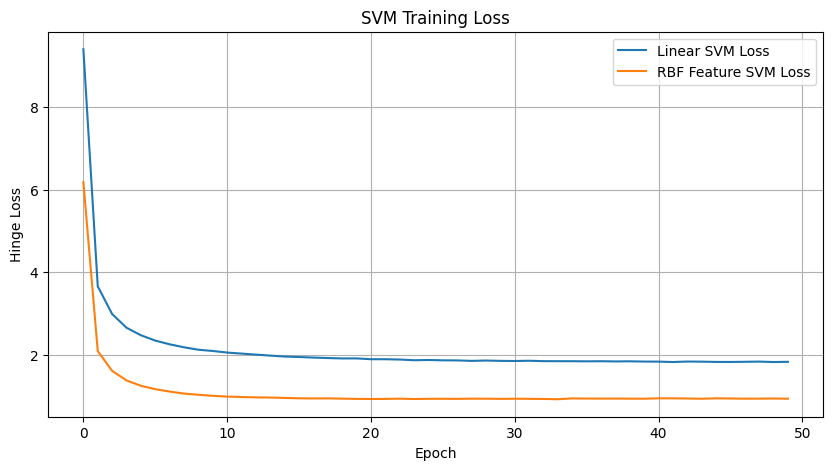

In [22]:
# ============================================================
# 21. 학습 손실 그래프
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 5))

# 선형 SVM 손실 곡선을 그립니다.
plt.plot(linear_loss_history, label="Linear SVM Loss")

# RBF 특징 SVM 손실 곡선을 그립니다.
plt.plot(rbf_loss_history, label="RBF Feature SVM Loss")

# 그래프 제목을 설정합니다.
plt.title("SVM Training Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Hinge Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 10단계. 최종 성능 비교

선형 SVM보다 RBF 커널 SVM의 정확도가 더 높게 나옵니다.
  
선형 모델과 RBF 특징 근사 모델의 정확도를 비교합니다.

In [23]:
# ============================================================
# 22. 선형 SVM과 RBF 특징 SVM 성능 비교
# ============================================================

# 결과를 DataFrame으로 정리합니다.
result_df = pd.DataFrame({
    "Model": ["Linear SVM", "RBF Feature SVM"],
    "Test Accuracy": [linear_acc, rbf_acc]
})

# 결과를 출력합니다.
result_df

,Model,Test Accuracy
0,Linear SVM,0.71175
1,RBF Feature SVM,0.91275


In [24]:
# ============================================================
# 23. 예측 결과 샘플 비교
# ============================================================

# 실제 문자 라벨을 복원합니다.
true_letters = label_encoder.inverse_transform(y_test)

# 비교할 샘플 개수를 지정합니다.
sample_count = 30

# 실제값, 선형 SVM 예측값, RBF SVM 예측값을 표로 정리합니다.
compare_df = pd.DataFrame({
    "Actual": true_letters[:sample_count],
    "Linear_SVM_Pred": linear_pred_letters[:sample_count],
    "RBF_Feature_SVM_Pred": rbf_pred_letters[:sample_count]
})

# 비교 결과를 출력합니다.
compare_df

,Actual,Linear_SVM_Pred,RBF_Feature_SVM_Pred
0,U,W,U
1,N,N,N
2,V,R,V
3,I,X,X
4,N,N,N
5,H,H,H
6,E,E,E
7,Y,Y,Y
8,G,G,C
9,E,E,E


In [26]:
import numpy as np
import pandas as pd

def sorted_confusions_from_cm(cm, class_names, exclude_diagonal=True):
    """
    cm: confusion matrix (numpy array or pandas DataFrame)
    class_names: list/array of class labels in order
    exclude_diagonal: True면 정답 맞춘 값(cm[i,i]) 제외하고 혼동만 계산
    """
    if isinstance(cm, pd.DataFrame):
        cm = cm.values

    records = []
    n = len(class_names)

    for i in range(n):
        row = cm[i].copy()

        if exclude_diagonal:
            row[i] = 0

        total_misclassified = row.sum()

        if total_misclassified == 0:
            continue

        # 해당 실제 문자에서 가장 많이 잘못 예측된 문자들 추출
        for j in np.argsort(row)[::-1]:
            if row[j] == 0:
                break
            records.append({
                "actual": class_names[i],
                "predicted": class_names[j],
                "count": int(row[j]),
                "actual_total_misclassified": int(total_misclassified),
                "misclass_rate_in_row": row[j] / total_misclassified
            })

    result = pd.DataFrame(records)
    result = result.sort_values(
        by=["count", "misclass_rate_in_row"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return result

# 예시: Linear SVM confusion matrix
cm_sorted_linear = sorted_confusions_from_cm(cm_linear, label_encoder.classes_)
display(cm_sorted_linear.head(20))

# 예시: RBF SVM confusion matrix
cm_sorted_rbf = sorted_confusions_from_cm(cm_rbf, label_encoder.classes_)
display(cm_sorted_rbf.head(20))

,actual,predicted,count,actual_total_misclassified,misclass_rate_in_row
0,O,H,47,84,0.559524
1,G,Q,34,103,0.330097
2,G,C,30,103,0.291262
3,S,Z,22,77,0.285714
4,K,R,21,44,0.477273
5,P,F,21,49,0.428571
6,Q,S,17,59,0.288136
7,C,K,15,41,0.365854
8,H,R,15,87,0.172414
9,F,T,13,43,0.302326


,actual,predicted,count,actual_total_misclassified,misclass_rate_in_row
0,P,F,17,37,0.459459
1,G,C,14,35,0.400000
2,D,B,8,11,0.727273
3,E,G,6,20,0.300000
4,R,H,6,20,0.300000
5,I,X,6,25,0.240000
6,C,E,5,10,0.500000
7,S,B,5,10,0.500000
8,K,R,5,15,0.333333
9,H,D,5,19,0.263158


In [27]:
# cm_sorted_linear 또는 cm_sorted_rbf 같은 결과 DataFrame 기준
# columns: actual, predicted, count, actual_total_misclassified, misclass_rate_in_row

merged_actual_linear = (
    cm_sorted_linear
    .groupby('actual', as_index=False)
    .agg({
        'count': 'sum',
        'actual_total_misclassified': 'first'
    })
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

display(merged_actual)

,actual,count,actual_total_misclassified
0,G,103,103
1,H,87,87
2,O,84,84
3,S,77,77
4,Q,59,59
5,P,49,49
6,E,44,44
7,Z,44,44
8,K,44,44
9,F,43,43


In [29]:
# cm_sorted_linear 또는 cm_sorted_rbf 같은 결과 DataFrame 기준
# columns: actual, predicted, count, actual_total_misclassified, misclass_rate_in_row

merged_actual_rbf = (
    cm_sorted_rbf
    .groupby('actual', as_index=False)
    .agg({
        'count': 'sum',
        'actual_total_misclassified': 'first'
    })
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

display(merged_actual)

,actual,count,actual_total_misclassified
0,P,37,37
1,G,35,35
2,I,25,25
3,E,20,20
4,R,20,20
5,H,19,19
6,O,16,16
7,K,15,15
8,L,15,15
9,N,13,13
